# Importaciones

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import emoji
import html
import re
from itertools import combinations
import ipywidgets as widgets
from IPython.display import display
import unicodedata


# Embedkit
from embedkit import EmbedKitAnalyzer

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import umap

# Machine Learning y NLP
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import FactorAnalysis
from sklearn.decomposition import PCA

# Auxiliares
from empath import Empath


# Sentence Transformers
from sentence_transformers import SentenceTransformer

#NLTK
import spacy
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag_sents

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       d

# Carga dataset

In [9]:
df = pd.read_parquet("Datasets\consolidado_rmhd.parquet")
df

,author,created_utc,score,selftext,subreddit,title,timestamp,year,month,dataset_type
0,tcarrollsmit,1567259968,21,Anyone here have IBS due to anxiety? Have you ...,Anxiety,IBS &amp; anxiety,2019-08-31 23:59:28,2019,aug,anxiety
1,Jane_Meki_Jane,1567258811,1,I was just browsing in a store avoiding the em...,Anxiety,Was gonna get what I thought I needed but turn...,2019-08-31 23:40:11,2019,aug,anxiety
2,G-Random20,1567258607,1,"Anxiety: -Hey, you should really worry about t...",Anxiety,If my anxiety could talk...,2019-08-31 23:36:47,2019,aug,anxiety
3,mimiforu,1567258357,1,It always seems like the hardest stuff happens...,Anxiety,I suffer from panic disorder and weekends seem...,2019-08-31 23:32:37,2019,aug,anxiety
4,G-Random20,1567257982,1,"Anxiety: -Hey, you should really worry about t...",Anxiety,If my anxiety could talk...,2019-08-31 23:26:22,2019,aug,anxiety
...,...,...,...,...,...,...,...,...,...,...
1851575,username1627,1651328267,1,"Whenever I see comments such as ""it will get b...",SuicideWatch,Useless Rant,2022-05-01 00:17:47,2022,may,suicidewatch
1851576,verycoolusername231,1651327988,1,What even is the purpose in life? Nothing. Lif...,SuicideWatch,There is nothing.,2022-05-01 00:13:08,2022,may,suicidewatch
1851577,mogana_sunset,1651327849,1,[removed],SuicideWatch,"Why am I still here, just to suffer?",2022-05-01 00:10:49,2022,may,suicidewatch
1851578,uaipqwhy,1651327604,1,2? Idk if I gonna or not do it. \nBut I hope I do,SuicideWatch,countdown,2022-05-01 00:06:44,2022,may,suicidewatch


In [10]:
df.columns

Index(['author', 'created_utc', 'score', 'selftext', 'subreddit', 'title',
       'timestamp', 'year', 'month', 'dataset_type'],
      dtype='str')

# Limpieza

## Autor

In [11]:
df.author.info()

<class 'pandas.Series'>
RangeIndex: 1851580 entries, 0 to 1851579
Series name: author
Non-Null Count    Dtype
--------------    -----
1851580 non-null  str  
dtypes: str(1)
memory usage: 36.3 MB


In [12]:
df.author.value_counts()

author
[deleted]               21080
h3xadecimal2              803
ThatWasNotEasy10          774
AnotherTrowaway12         533
AshleyJames_              520
                        ...  
Marcus644                   1
Ok-Satisfaction9739         1
Electronic-Farmer-19        1
The_unknown_user602         1
username1627                1
Name: count, Length: 850515, dtype: int64

Se eliminan autores [deleted] para evitar el ruido. Se reconoce que en caso de que no esté el autor es porque su cuenta ya no está activa.

In [13]:
df.loc[df["author"]=="[deleted]","author"] = np.nan

## Created_utc y Timestamp

Se verifica que ambas columnas contengan la misma información. Tras realizar validaciones, se verifica que timestamp está en hora Australiana de Sydney

In [14]:
df_hora = df.copy()
df_hora["conversion"] = pd.to_datetime(df["created_utc"], unit = "s", utc=True).dt.tz_convert("Australia/Sydney").dt.tz_localize(None)

In [15]:
df_hora[~(df_hora["conversion"] == df["timestamp"])][["conversion","timestamp"]]

,conversion,timestamp


Se elimina la UTC, preservando únicamente la fecha

In [16]:
df.drop(columns=["created_utc"], inplace=True)

In [17]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [18]:
posts_por_dia = df.set_index("timestamp").resample("D").size()
posts_por_dia

timestamp
2019-01-01    1116
2019-01-02    1061
2019-01-03    1093
2019-01-04     914
2019-01-05     820
              ... 
2022-08-27    1461
2022-08-28    1559
2022-08-29    1569
2022-08-30    1644
2022-08-31    1580
Freq: D, Length: 1339, dtype: int64

Se esperaría que la mayoría de post se realizaran en la noche/madrugada, pero en este caso es todo lo contrario. ¿Qué tan fiable es la hora?. Depende de la ubicación del usuario (información que no se tiene)

In [19]:
df["timestamp"].dt.hour.value_counts().sort_index(ascending=True)

timestamp
0     60544
1     66310
2     72105
3     77436
4     81913
5     85243
6     88764
7     91005
8     92598
9     92682
10    93763
11    94684
12    96845
13    96397
14    95471
15    89418
16    80875
17    71556
18    62434
19    55624
20    50650
21    49378
22    50871
23    55014
Name: count, dtype: int64

¿Qué tan útil puede ser teniendo mes y año?

## Score

In [20]:
df.score.info()

<class 'pandas.Series'>
RangeIndex: 1851580 entries, 0 to 1851579
Series name: score
Non-Null Count    Dtype
--------------    -----
1851580 non-null  int64
dtypes: int64(1)
memory usage: 14.1 MB


In [21]:
round(df.score.describe(),3)

count    1851580.000
mean           2.758
std           33.137
min            0.000
25%            1.000
50%            1.000
75%            1.000
max         5863.000
Name: score, dtype: float64

In [22]:
df.score.value_counts()

score
1       1606870
2         96023
3         47796
4         17469
5         14015
         ...   
1085          1
826           1
1004          1
1320          1
1941          1
Name: count, Length: 1276, dtype: int64

Teniendo en cuenta la distribución de la variable, la información que oculta (un post puede tener alto impacto y aún así confundirse con otros post que tengan poca relevancia), el no reflejar la interacción real (muchos usuarios pueden verlos sin interactuar, o comentar en vez de votar, aún más en comunidades de salud mental).

Se podría utilizar como auxiliar, incluso revisar en detalle los más votados, pero considero que incluirlo en el grafo general puede llevara conclusiones erróneas.

## Subreddit y dataset_type

Se verifica que coincidad

In [23]:
df.subreddit.unique()

<ArrowStringArray>
['Anxiety', 'depression', 'lonely', 'mentalhealth', 'SuicideWatch']
Length: 5, dtype: str

In [24]:
df.dataset_type.unique()

<ArrowStringArray>
['anxiety', 'depression', 'lonely', 'mentalhealth', 'suicidewatch']
Length: 5, dtype: str

In [25]:
df["dataset_type"] = df["dataset_type"].replace({"anxiety":"Anxiety",
                            "suicidewatch":"SuicideWatch"})

In [26]:
df[~(df["dataset_type"]==df["subreddit"])]

,author,score,selftext,subreddit,title,timestamp,year,month,dataset_type
127291,grossenten98,1,Why ACT why?! Is this some type of joke?,SuicideWatch,Why won’t they release my ACT Test scores!?,2019-12-31 23:57:59,2019,dec,depression
127292,konsertt,1,Right now im cutting my wrist and drinking asp...,SuicideWatch,It's new years eve and im out here trying to k...,2019-12-31 23:51:29,2019,dec,depression
127293,VincentXVIII,1,"A question one must ponder for themselves, tho...",SuicideWatch,Why live?,2019-12-31 23:46:49,2019,dec,depression
127294,Artemis_Prima_Donna,1,Are the mornings. My alarm used to wake me up ...,SuicideWatch,The worst parts,2019-12-31 23:38:33,2019,dec,depression
127295,ErrorThrowAway404,1,It's time to get off my depressed ass and fina...,SuicideWatch,Today's the day or rather tonight's the night,2019-12-31 23:32:06,2019,dec,depression
...,...,...,...,...,...,...,...,...,...
1748572,DescriptionGreen6921,1,Have you ever tried to just give up on everyth...,mentalhealth,r/everyone,2022-06-01 00:54:05,2022,jun,SuicideWatch
1748573,Discovery_Tank,1,"For a long time I’ve had difficult emotions, v...",mentalhealth,My parents are being difficult on letting me s...,2022-06-01 00:54:04,2022,jun,SuicideWatch
1748574,BeatRedditor,1,Me and my dad got into a fight today because I...,mentalhealth,I told my Dad I hate him.,2022-06-01 00:37:15,2022,jun,SuicideWatch
1748575,sincerelyxme_,1,So by the title it might not seem like a big d...,mentalhealth,I’m going on a five day trip,2022-06-01 00:22:56,2022,jun,SuicideWatch


In [27]:
depression = df.loc[(df["year"]==2019)&(df["month"]=="dec")&(df["dataset_type"]=="depression"),["selftext","title"]].reset_index()
suicide = df.loc[(df["year"]==2019)&(df["month"]=="dec")&(df["dataset_type"]=="SuicideWatch"),["selftext","title"]].reset_index()

In [28]:
depression

,index,selftext,title
0,127291,Why ACT why?! Is this some type of joke?,Why won’t they release my ACT Test scores!?
1,127292,Right now im cutting my wrist and drinking asp...,It's new years eve and im out here trying to k...
2,127293,"A question one must ponder for themselves, tho...",Why live?
3,127294,Are the mornings. My alarm used to wake me up ...,The worst parts
4,127295,It's time to get off my depressed ass and fina...,Today's the day or rather tonight's the night
...,...,...,...
7959,135250,I cannot bear it anymore.\n\nI've got a job it...,Ciao
7960,135251,i thought i’d be panicking but im not?? i just...,impulsively swallowed some pills LMAO
7961,135252,I’ve literally just turned 14 about a month ag...,I don’t know what to do anymore
7962,135253,NaN,What can I include in my suicide note that wil...


In [29]:
depression[~(depression.selftext == suicide.selftext)]

,index,selftext,title
39,127330,NaN,Another day different year same stupid meaning...
41,127332,NaN,"I failed before, this new years I will succeed..."
71,127362,NaN,I cheated on my partner. I told them. I feel t...
85,127376,NaN,Ready to eat a bullet.
89,127380,NaN,Sig Sauer is my friend.
...,...,...,...
7915,135206,NaN,I'm a bisexual guy and I love her. I can never...
7924,135215,NaN,No one wants me
7927,135218,NaN,Will somebody please help me kill myself?
7934,135225,NaN,"I don't want help, just give me quick methods ..."


In [30]:
(depression[(depression.selftext.isna())&(suicide.selftext.isna())&(depression.title==suicide.title)].index == depression[~(depression.selftext == suicide.selftext)].index).sum()

np.int64(429)

Se identifica que para diciembre de 2019 en depression se pusieron los registros de SuicideWatch. Se limpia

In [31]:
eliminar = df.loc[(df["year"]==2019)&(df["month"]=="dec")&(df["dataset_type"]=="depression")].index
df.drop(eliminar, inplace = True)

Se verifican duplicados

In [32]:
df[df.duplicated(keep=False, subset=["author","score","selftext","subreddit","title", "year","month","dataset_type"])]

,author,score,selftext,subreddit,title,timestamp,year,month,dataset_type
5,yungalcoholicsanon,1,I work guest relations at the Zoo so I’m expec...,Anxiety,I don’t want to be at work right now but I’m here,2019-08-31 23:19:59,2019,aug,Anxiety
6,yungalcoholicsanon,1,I work guest relations at the Zoo so I’m expec...,Anxiety,I don’t want to be at work right now but I’m here,2019-08-31 23:16:44,2019,aug,Anxiety
1756,DelayDelayDelay20,1,[removed],Anxiety,I don't know what to do anymore [Triggers],2019-08-21 14:05:11,2019,aug,Anxiety
1762,DelayDelayDelay20,1,[removed],Anxiety,I don't know what to do anymore [Triggers],2019-08-21 13:21:20,2019,aug,Anxiety
3108,JK_1288,1,[removed],Anxiety,Everyone Hates Me.,2019-08-14 06:04:10,2019,aug,Anxiety
...,...,...,...,...,...,...,...,...,...
1850738,InsidiousmysteryX27,1,[removed],SuicideWatch,My reality is a lie.,2022-05-02 13:50:08,2022,may,SuicideWatch
1851380,catatawea,1,I hate my life I hate myself I hate everything...,SuicideWatch,There is always something more important,2022-05-01 09:27:30,2022,may,SuicideWatch
1851381,catatawea,1,I hate my life I hate myself I hate everything...,SuicideWatch,There is always something more important,2022-05-01 09:27:15,2022,may,SuicideWatch
1851441,carbonatedbubbles,1,"I'm suicidal. I have a plan, and intentions of...",SuicideWatch,"I'm suicidal, but can't do anything to help my...",2022-05-01 06:53:58,2022,may,SuicideWatch


Dada la dificultad que implicaría esto al modelado (más allá de la razón por la que salan duplicados, se decide eliminarlos)

In [33]:
df.drop_duplicates(subset=["author","score","selftext","subreddit","title", "year","month","dataset_type"],inplace=True)

Ahora se verifican los duplicados por texto (que recurran en el ejemplo ya identificado)

In [34]:
df[df.duplicated(subset=["selftext","title","year","month"], keep = False)][df.subreddit != df.dataset_type][["subreddit","dataset_type","year","month"]].drop_duplicates()

,subreddit,dataset_type,year,month
1739832,mentalhealth,SuicideWatch,2022,jun


In [35]:
df.loc[(df["year"]==2022)&(df["month"]=="jun")&(df["subreddit"]=="mentalhealth"),["selftext","title"]].reset_index()

,index,selftext,title
0,1731087,I don't want to go into detail. It's just one ...,I Think I Have A Hoarding Problem
1,1731088,looking to get FREE mental health advice from ...,free mental health advice
2,1731089,I feel like my life up to this point has been ...,My life is worthless and I’m spiraling
3,1731090,"I heard my sister, someone who has chronic anx...",“Happiness is a Choice” - do we all agree this...
4,1731091,So basically I’m an international high school ...,I’m freaking out right now and Idk what to do ...
...,...,...,...
17331,1748572,Have you ever tried to just give up on everyth...,r/everyone
17332,1748573,"For a long time I’ve had difficult emotions, v...",My parents are being difficult on letting me s...
17333,1748574,Me and my dad got into a fight today because I...,I told my Dad I hate him.
17334,1748575,So by the title it might not seem like a big d...,I’m going on a five day trip


In [36]:
df.loc[(df["year"]==2022)&(df["month"]=="jun")&(df["dataset_type"]=="SuicideWatch"),["selftext","title"]].reset_index(drop=True)

,selftext,title
0,I don't want to go into detail. It's just one ...,I Think I Have A Hoarding Problem
1,looking to get FREE mental health advice from ...,free mental health advice
2,I feel like my life up to this point has been ...,My life is worthless and I’m spiraling
3,"I heard my sister, someone who has chronic anx...",“Happiness is a Choice” - do we all agree this...
4,So basically I’m an international high school ...,I’m freaking out right now and Idk what to do ...
...,...,...
8663,Have you ever tried to just give up on everyth...,r/everyone
8664,"For a long time I’ve had difficult emotions, v...",My parents are being difficult on letting me s...
8665,Me and my dad got into a fight today because I...,I told my Dad I hate him.
8666,So by the title it might not seem like a big d...,I’m going on a five day trip


In [37]:
df1 = df.loc[
    (df["year"] == 2022) &
    (df["month"] == "jun") &
    (df["dataset_type"] == "mentalhealth"),
    ["selftext", "title"]
].reset_index(drop=True)

df2 = df.loc[
    (df["year"] == 2022) &
    (df["month"] == "jun") &
    (df["dataset_type"] == "SuicideWatch"),
    ["selftext", "title"]
].reset_index(drop=True)

In [38]:
df1[~(df1.selftext == df2.selftext)].selftext

114     NaN
201     NaN
204     NaN
274     NaN
305     NaN
       ... 
8314    NaN
8544    NaN
8552    NaN
8600    NaN
8631    NaN
Name: selftext, Length: 129, dtype: str

Se identifica que para Junio de 2022 no se recopilaron datos de SuicideWatch, y en su archivo respectivo se repitió información de mentalhealth. Se eliminan duplicados

In [39]:
eliminar = df.loc[(df["year"]==2022)&(df["month"]=="jun")&(df["dataset_type"]=="SuicideWatch")].index
df.drop(eliminar, inplace = True)

In [40]:
df[~(df["dataset_type"]==df["subreddit"])]

,author,score,selftext,subreddit,title,timestamp,year,month,dataset_type


Dado que ya coinciden, se elimina una de las columnas

In [41]:
df.drop(columns=["dataset_type"], inplace=True)

In [42]:
df.subreddit.value_counts()

subreddit
depression      623539
SuicideWatch    473357
mentalhealth    292715
Anxiety         278927
lonely          155133
Name: count, dtype: int64

## Year y month

In [43]:
df.year.value_counts()

year
2021    575747
2020    499454
2022    377190
2019    371280
Name: count, dtype: int64

In [44]:
df.month.value_counts()

month
jul    176990
aug    175958
jan    173082
apr    160140
may    159915
jun    157961
feb    152573
mar    147091
nov    137967
oct    130375
dec    127245
sep    124374
Name: count, dtype: int64

Se verifica que las columnas sean consistentes con el timestamp

In [45]:
df[~(df["timestamp"].dt.strftime("%b").str.lower() == df.month)]

,author,score,selftext,subreddit,title,timestamp,year,month
1084103,Spiritual_Ad_8365,1,[removed],depression,My parents make jokes about how they never sho...,2021-02-01 00:00:59,2021,jan


Dado que el mes se extrajo manualmente, prevalece el timestamp y se corrige el mes correspondiente

In [46]:
df.loc[1084103,"month"] = "feb"

In [47]:
df[~(df["timestamp"].dt.year == df.year)]

,author,score,selftext,subreddit,title,timestamp,year,month


A pesar de que es información redundante con el timestamp, conservarlas puede facilitar el modelamiento, por lo que se mantienen

## Selftext y title

### Title

Se identifican carácteres incorrectos, no transformados o no acordes a la estructura

In [48]:
df["title"].sample(50, random_state=42).tolist()

['Is there any method?',
 'How long will it take to get over the loss of a close friend?',
 'I keep having extreme anger episodes that are impossible to control [M16]',
 'My dad said my depression embarrasses him',
 'i dont wanna die i just want people to think of me',
 'Going back.',
 'Any clue how much warfarin is lethal for an average man?',
 "I'm done with everything. Not man enough to kill myself. Tried and failed. My only hope now is to somehow die. Sooner the better. I have no desire to carry on with this miserable life. I'm sorry. But I'm done.",
 'Do u guys ever have anxiety to the point u guys want to throw up or use the bathroom bc it’s so inconvenient….',
 'My heart hurts and I want to die',
 "I literally need to kill myself tonight, I'm gonna do it but I'm scared",
 'after 8 years?',
 'I want kill myself! Fucking hell!',
 'Does anyone else feel afraid to better ones self? Any tips on feeling less lonely?',
 'Cant talk to anyone.',
 'So... What was that!?',
 "the cure is a 

In [49]:
df["title"].value_counts().head(50)

title
Help                               2753
I need help                        2086
.                                  1514
I want to die                      1419
I hate myself                       973
I don't know what to do             912
Tired                               909
I don’t know what to do             883
help                                874
Goodbye                             777
Lonely                              760
Please help                         748
Idk                                 691
Hi                                  680
Alone                               663
Question                            654
I’m done                            613
Why                                 606
I'm tired                           587
Please help me                      579
Depression                          578
I'm done                            555
Suicide                             554
:(                                  550
Help me                           

In [50]:
patterns = [
    "[deleted]",
    "[removed]",
    "nan",
    "none",
    ""
]

for p in patterns:
    print(p, (df["title"].str.lower() == p).sum())

[deleted] 0
[removed] 0
nan 0
none 1
 0


In [51]:
df[df["title"] == "none"]

,author,score,selftext,subreddit,title,timestamp,year,month
558275,Godfather1960,1,"I have had many people tell me, what do you ha...",depression,none,2020-01-31 07:46:57,2020,jan


In [52]:
df[df["title"].str.contains(r"http|www\.", regex=True, na=False)]

,author,score,selftext,subreddit,title,timestamp,year,month
1662,NaN,1,Please I need to know what to do. [TRIGGERS],Anxiety,https://www.reddit.com/r/Anxiety/comments/ctlr...,2019-08-22 05:30:39,2019,aug
2449,fusionblast,2,I kept saying this this morning over and over ...,Anxiety,Man this helped this morning. LOL. https://you...,2019-08-17 22:24:13,2019,aug
3533,meganghxfv,0,NaN,Anxiety,Made a blog about my anxiety https://belcherme...,2019-08-11 22:29:15,2019,aug
9300,OdmaSad,1,[removed],depression,depression healed 80% in 2 days (cant imagine ...,2019-08-23 21:57:25,2019,aug
10480,NaN,1,This post is not about me,depression,https://www.reddit.com/r/depression/comments/c...,2019-08-21 09:27:11,2019,aug
...,...,...,...,...,...,...,...,...
1850348,NaN,1,So yeah i guess im going to kill myself soon. ...,SuicideWatch,https://www.reddit.com/r/SuicideWatch/comments...,2022-05-03 08:45:31,2022,may
1850369,NaN,1,think i was shadowbanned here?,SuicideWatch,https://www.reddit.com/r/SuicideWatch/comments...,2022-05-03 07:52:14,2022,may
1851120,NaN,1,I wanna die,SuicideWatch,https://www.reddit.com/r/SuicideWatch/comments...,2022-05-01 19:46:33,2022,may
1851130,NaN,1,I regret not transitioning sooner as a trans p...,SuicideWatch,https://www.reddit.com/r/SuicideWatch/comments...,2022-05-01 18:57:23,2022,may


In [53]:
df[df["title"].str.contains(r"<.*?>", regex=True, na=False)]

,author,score,selftext,subreddit,title,timestamp,year,month


In [54]:
text = " ".join(df["title"].dropna().astype(str))
Counter(text).most_common(50)

[(' ', 15228604),
 ('e', 7497788),
 ('t', 5350615),
 ('o', 5078956),
 ('n', 4651219),
 ('a', 4502555),
 ('i', 4444936),
 ('s', 3714961),
 ('l', 2900820),
 ('r', 2861503),
 ('h', 2515144),
 ('d', 2483355),
 ('m', 1944638),
 ('y', 1873703),
 ('u', 1643518),
 ('g', 1576194),
 ('f', 1350294),
 ('p', 1257561),
 ('c', 1246643),
 ('w', 1196523),
 ('I', 1140145),
 ('b', 812210),
 ('k', 767851),
 ('v', 711409),
 ('.', 666497),
 ('?', 390590),
 ("'", 328043),
 ('’', 263110),
 (',', 233037),
 ('x', 221564),
 ('A', 205288),
 ('H', 168748),
 ('T', 160939),
 ('S', 160337),
 ('W', 156898),
 ('j', 150228),
 ('D', 147794),
 ('M', 137866),
 ('C', 90404),
 ('E', 89515),
 ('F', 89224),
 ('N', 88710),
 ('/', 80161),
 ('L', 79318),
 ('P', 76965),
 ('O', 61837),
 ('R', 54874),
 ('B', 54602),
 ('2', 51947),
 ('(', 51939)]

**Carácteres a limpiar:**
- Emojis
- Títulos vacíos ("none", ".", "...")
- Manejo de enlaces
- \n

Se limpia conforme lo detectado en un primer vistazo

In [55]:
bad_titles = [
    "",
    ".",
    "..",
    "...",
    "none",
    "null",
    "nan",
]

df["title"] = (
    df["title"]
    .apply(lambda x: emoji.demojize(x) if pd.notna(x) else x)
    .str.replace(r"http\S+|www\.\S+", " URL ", regex=True)
    .str.replace(r"\n+", "\n", regex=True)
    .str.strip()
    .replace(bad_titles, pd.NA)
)

In [56]:
df["title"] = df["title"].apply(
    lambda x: html.unescape(x) if pd.notna(x) else x
)

### Selftext

Se identifican carácteres incorrectos, no transformados o no acordes a la estructura

In [57]:
df["selftext"].sample(50, random_state=42).tolist()

["I don't have a gun and I fear hanging would fail and make my life even harder. Throwing myself under a train might be too painful and I don't want to make people's day by making them be late to wherever they're going just because of myself.\n\nI wonder if I can just mix some legal pills and put an end to this once and for all. I don't want anyone to change my mind. I just want advice on how to do this. If there's smother painless, accesible method, I'm all ears.",
 ' About three months ago I lost an online friend, he killed himself. We never met face-to-face but our friendship still meant so much to me. I\'m really isolated, I don\'t speak to my family, I don\'t have any friends, I\'m basically a hermit.\n\nOur friendship wasn\'t the healthiest for me when I think about it, he was addicted to drugs, and I subconsciously mimicked his drug abuse, I started doing the same drugs as him (except for heroin, I hate opiates), it wasn\'t his fault, of course.\n\nHe always told me to slow down

In [58]:
df["selftext"].value_counts().head(50)

selftext
[removed]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [59]:
patterns = [
    "[deleted]",
    "[removed]",
    "nan",
    "none",
    ""
]

for p in patterns:
    print(p, (df["selftext"].str.lower() == p).sum())

[deleted] 16898
[removed] 161293
nan 0
none 1
 0


In [60]:
df[df["selftext"].str.contains(r"http|www\.", regex=True, na=False)]

,author,score,selftext,subreddit,title,timestamp,year,month
37,winningwriters,1,"Dear poets of /r/anxiety,\n\nI'm from a writer...",Anxiety,Creating opportunities for poets with anxiety ...,2019-08-31 15:45:13,2019,aug
61,XBionicForSpaceX,2,"No other symptoms, only saw it cuz i zoomed. h...",Anxiety,"Hey, I don’t know if this goes here but my hea...",2019-08-31 12:36:21,2019,aug
71,rehuxley,1,I have free online courses on getting free fro...,Anxiety,Freedom from Anxiety online course,2019-08-31 10:59:27,2019,aug
95,odiams,2,https://youtu.be/nzgTM6ArASI \n\nPlease wait a...,Anxiety,Don't know if this is allowed or not found the...,2019-08-31 07:56:16,2019,aug
129,the05Nib,3,Okidoki so heres the deal. I came out as gay t...,Anxiety,Non stop horrible anxiety after coming out to ...,2019-08-31 04:23:28,2019,aug
...,...,...,...,...,...,...,...,...
1848418,AtypicalGuy12345,1,Work ended. Rolled away from my desk. Looked a...,SuicideWatch,It's the weekend and all I want to do is die,2022-05-07 11:43:09,2022,may
1848706,Giblygibs,1,In my case reaching out worked for only a time...,SuicideWatch,I'm not really sure what to title this but it ...,2022-05-06 20:52:04,2022,may
1849467,Anna__V,1,"Everything is being taken away, even my dreams...",SuicideWatch,Why do I have to live?,2022-05-05 04:57:53,2022,may
1850524,BrawlerMage,1,I had surgery in the beginning of March and th...,SuicideWatch,I don't know what to do,2022-05-03 01:08:09,2022,may


In [61]:
df[df["selftext"].str.contains(r"<.*?>", regex=True, na=False)]

,author,score,selftext,subreddit,title,timestamp,year,month


In [62]:
text = " ".join(df["selftext"].dropna().astype(str))
Counter(text).most_common(50)

[(' ', 270731504),
 ('e', 128847735),
 ('t', 100791191),
 ('a', 83703159),
 ('o', 82951929),
 ('n', 77300909),
 ('i', 70260685),
 ('s', 64381669),
 ('h', 51846764),
 ('r', 50027643),
 ('l', 47770897),
 ('d', 43167896),
 ('m', 34907849),
 ('u', 29752578),
 ('y', 29746014),
 ('g', 25789402),
 ('f', 23252625),
 ('w', 23147826),
 ('c', 22430333),
 ('I', 19931668),
 ('p', 18855713),
 ('b', 17190651),
 ('.', 16341441),
 ('v', 13445091),
 ('k', 12615943),
 (',', 9047754),
 ('\n', 6299628),
 ("'", 6031515),
 ('’', 4560754),
 ('j', 3074224),
 ('x', 2289801),
 ('T', 1768279),
 ('A', 1641317),
 ('S', 1217607),
 ('?', 1153231),
 ('M', 950900),
 ('W', 843118),
 ('H', 826018),
 ('B', 810927),
 (')', 773854),
 ('(', 759301),
 ('0', 737635),
 ('2', 737111),
 ('E', 713897),
 ('-', 690991),
 ('N', 672947),
 ('1', 660495),
 ('"', 644013),
 ('z', 598195),
 ('D', 592633)]

**Carácteres a limpiar:**
- [removed]
- [deleted]
- Comentarios vacíos (., ..., Title, Pls, )
- Manejo de \ para '
- Manejo de enlaces
- \n

Se limpia de acuerdo al primer vistazo

In [63]:
bad_titles = [
    "",
    ".",
    "..",
    "...",
    "none",
    "null",
    "nan",
    "title",
    "pls",
    "please",
    "[deleted]",
    "[removed]"
]

df["selftext"] = (
    df["selftext"]
    .apply(lambda x: emoji.demojize(x) if pd.notna(x) else x)
    .str.replace(r"https?://\S+|www\.\S+", " URL ", regex=True)
    .str.replace(r"\\'","'", regex = True)
    .str.replace(r"\n+", "\n", regex=True)
    .str.strip()
    .replace(bad_titles, pd.NA)
)

df.loc[df["selftext"].str.fullmatch(r"[.\-_]+", na=False), "selftext"] = pd.NA
df.loc[df["selftext"].str.lower().isin(bad_titles),"selftext"] = pd.NA

In [64]:
df["selftext"] = df["selftext"].apply(
    lambda x: html.unescape(x) if pd.notna(x) else x
)

Para fines del grafo, se decide crear una nueva columna que una ambos textos, preservando las originales para mantener información

In [65]:
def combine_text(title,selftext):
    title = "" if pd.isna(title) else str(title).strip()
    selftext = "" if pd.isna(selftext) else str(selftext).strip()
    if not title:
        return selftext
    elif not selftext:
        return title
    if title.lower() in selftext.lower():
        return selftext
    return title + " " + selftext

df["text"] = df.apply(
    lambda row: combine_text(row["title"], row["selftext"]), axis  = 1
)

In [66]:
df["selftext"] = (
    df["selftext"]
    .str.replace(r"\[.*?\]\(https?:\/\/.*?(?:\s|\))", "", regex=True)
    .str.replace(r"https://", "", regex=True)
    .str.replace(r"https:", "", regex=True)
    .str.replace(r"https?:\/\/\S+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("`","'")
    .str.replace("’","'")
    .str.strip()
)

In [67]:
df[df["selftext"].str.contains(r"http|www\.", regex=True, na=False)]["selftext"]

46119                                    Aww I'm sorry awww.
79084      These are the days I want to give up, say fuck...
179656     is the wave of calm you the falls over you as ...
227791     There's alot more to my story but dont feel li...
228715     There's alot more to my story but dont feel li...
228918     There's alot more to my story but dont feel li...
321209     I got into a really bad state because of the f...
389454     I am really overwhelmed right nowwww. I keep g...
422892     Dealing with my own nerves and social anxiety,...
429987     They aren't. I was sad, anxious and use to hat...
440293     (23f) Currently listening to my nostalgia play...
467947     I can't cry. I don't know if it's cuz of the m...
490688     I can't cry. I don't know if it's cuz of the m...
515661     Hey everyone, So for the past week or so my an...
635694     Man, putting yourself out there is hard and be...
635904                  URL reduction explained](http:// URL
658059     Fuck, man. Je

Se eliminan aquellos registros que quedaron nulos en selftext y title

In [68]:
df.drop(df[df["text"]==""].index, inplace=True)
df = df.reset_index(drop = True)

### Preprocesamiento del texto

Para facilitar el tratamiento del texto por parte de los modelos, se normaliza, tokeniza, se eliminan stopwords y se lematiza

In [ ]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
USER_RE = re.compile(r"\bu/\w+")
SUBREDDIT_RE = re.compile(r"\br/\w+")
REMOVED_RE = re.compile(r"\[deleted\]|\[removed\]", flags=re.IGNORECASE)
WHITESPACE_RE = re.compile(r"\s+")


def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = URL_RE.sub(" ", text)
    text = USER_RE.sub(" ", text)
    text = SUBREDDIT_RE.sub(" ", text)
    text = REMOVED_RE.sub(" ", text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text


nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


def clean_text_column(
    series: pd.Series,
    batch_size: int = 500,
    n_process: int = 1,
) -> pd.Series:
    """
    Limpia una columna completa de texto usando spaCy.

    batch_size: cuántos documentos procesa spaCy internamente por lote.
                Valores típicos: 200-1000. Súbelo si tienes suficiente RAM.
    n_process:  número de procesos paralelos. Ponlo en el número de
                núcleos disponibles .
    """
    normalized_texts = series.fillna("").map(normalize_text).tolist()

    results = []
    for doc in nlp.pipe(normalized_texts, batch_size=batch_size, n_process=n_process):
        tokens = [
            t.lemma_
            for t in doc
            if t.is_alpha and not t.is_stop
        ]
        results.append(" ".join(tokens))

    return pd.Series(results, index=series.index)


if __name__ == "__main__":    
    df["text_clean"] = clean_text_column(df["text"], batch_size=500, n_process=4)

In [ ]:
# lemmatizer = WordNetLemmatizer()

# stop_words = set(stopwords.words("english"))

# def get_wordnet_pos(tag):
#     """Convierte POS tags de NLTK a WordNet."""
    
#     if tag.startswith("J"):
#         return wordnet.ADJ
#     elif tag.startswith("V"):
#         return wordnet.VERB
#     elif tag.startswith("N"):
#         return wordnet.NOUN
#     elif tag.startswith("R"):
#         return wordnet.ADV
    
#     return wordnet.NOUN


# def clean_text(text):

#     if not isinstance(text, str):
#         return ""

#     # 1. Eliminar elementos no semánticos
#     text = re.sub(r"https?://\S+|www\.\S+", " ", text)
#     text = re.sub(r"\bu/\w+", " ", text)
#     text = re.sub(r"\br/\w+", " ", text)
#     text = re.sub(
#         r"\[deleted\]|\[removed\]",
#         " ",
#         text,
#         flags=re.IGNORECASE
#     )

#     # Convertir entidades HTML
#     text = html.unescape(text)

#     # 2. Normalización
#     text = unicodedata.normalize("NFKC", text)
#     text = text.lower()
#     text = re.sub(r"\s+", " ", text).strip()

#     # 3. Tokenización
#     tokens = word_tokenize(text)

#     # 4. POS tagging
#     tagged_tokens = pos_tag(tokens)

#     # 5. Stopwords + lematización
#     clean_tokens = []

#     for token, tag in tagged_tokens:

#         # Solo palabras
#         if not token.isalpha():
#             continue

#         # Eliminar stopwords
#         if token in stop_words:
#             continue

#         # Lematizar usando categoría gramatical
#         lemma = lemmatizer.lemmatize(
#             token,
#             get_wordnet_pos(tag)
#         )

#         clean_tokens.append(lemma)

#     return " ".join(clean_tokens)

# df["text_clean"] = df["text"].apply(clean_text)

OSError: handle is closed

In [ ]:
df.to_parquet("Datasets/RMHD_Procesado.parquet")

# Grafo

In [2]:
df = pd.read_parquet("RMHD_Procesado.parquet")
df

,author,score,selftext,subreddit,title,timestamp,year,month,text
0,tcarrollsmit,21,Anyone here have IBS due to anxiety? Have you ...,Anxiety,IBS & anxiety,2019-08-31 23:59:28,2019,aug,IBS & anxiety Anyone here have IBS due to anxi...
1,Jane_Meki_Jane,1,I was just browsing in a store avoiding the em...,Anxiety,Was gonna get what I thought I needed but turn...,2019-08-31 23:40:11,2019,aug,Was gonna get what I thought I needed but turn...
2,G-Random20,1,"Anxiety: -Hey, you should really worry about t...",Anxiety,If my anxiety could talk...,2019-08-31 23:36:47,2019,aug,"If my anxiety could talk... Anxiety: -Hey, you..."
3,mimiforu,1,It always seems like the hardest stuff happens...,Anxiety,I suffer from panic disorder and weekends seem...,2019-08-31 23:32:37,2019,aug,I suffer from panic disorder and weekends seem...
4,G-Random20,1,"Anxiety: -Hey, you should really worry about t...",Anxiety,If my anxiety could talk...,2019-08-31 23:26:22,2019,aug,"If my anxiety could talk... Anxiety: -Hey, you..."
...,...,...,...,...,...,...,...,...,...
1823464,username1627,1,"Whenever I see comments such as ""it will get b...",SuicideWatch,Useless Rant,2022-05-01 00:17:47,2022,may,"Useless Rant Whenever I see comments such as ""..."
1823465,verycoolusername231,1,What even is the purpose in life? Nothing. Lif...,SuicideWatch,There is nothing.,2022-05-01 00:13:08,2022,may,There is nothing. What even is the purpose in ...
1823466,mogana_sunset,1,NaN,SuicideWatch,"Why am I still here, just to suffer?",2022-05-01 00:10:49,2022,may,"Why am I still here, just to suffer?"
1823467,uaipqwhy,1,2? Idk if I gonna or not do it. But I hope I do,SuicideWatch,countdown,2022-05-01 00:06:44,2022,may,countdown 2? Idk if I gonna or not do it. \nBu...


Se realiza un muestreo para agilizar el proceso y facilitar la depuración

In [ ]:
# df = (
#     df.groupby("subreddit")
#       .apply(lambda x: x.sample(
#           int(10000 * len(x) / len(df)),
#           random_state=42
#       )).reset_index()
# )
# df.drop(columns = ["level_1"], inplace=True)

## Embeddings

Dada la complejidad del lenguaje en Reddit (sarcasmo, polisemias, abreviaciones, extranjerismos), los embeddings requieren enfoques más complejos que permitan captar el contexto y el contenido. Por tal motivo, se utiliza BAAI, un modelo entrenado y enfocado en inglés que, publicado en 2024, estableció un estado del arte, garantizando calidad ante comentarios variados.

https://arxiv.org/abs/2402.03216

In [4]:
EMBEDDING_CACHE = "embeddings_cache.npy"        

def compute_embeddings(texts, model_name='all-MiniLM-L6-v2', cache_path=None, batch_size=64):    
    print(f"🔄 Calculando embeddings con {model_name}...")
    model = SentenceTransformer(model_name)
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True
    )
    
    if cache_path:
        np.save(cache_path, embeddings)
        print(f"Embeddings guardados en {cache_path}")
    
    return embeddings

embeddings = compute_embeddings(
    df['text'].tolist(),
    model_name='BAAI/bge-m3',
)

df['embedding_idx'] = range(len(df))

print(f"\\n Embeddings shape: {embeddings.shape}")
print(f"   Dimensión por post: {embeddings.shape[1]}")
print(f"   Memoria aproximada: {embeddings.nbytes / 1e6:.1f} MB")


🔄 Calculando embeddings con BAAI/bge-m3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

\n Embeddings shape: (9998, 1024)
   Dimensión por post: 1024
   Memoria aproximada: 41.0 MB


Carga de embeddings y dataset

In [ ]:
embeddings = np.load("embeddings_bge.npy")
df = pd.read_parquet("reddit_posts.parquet")

Se hace uso de Embedkit para analizar las métricas del embedding creado, permitiendo reducir dimensionalidad, mejorar su calidad y garantizar representaciones precisas.

Dado que la librería realiza el análisis a partir de la selección el hiperparámetro k, se prueban con varios valores

In [8]:
for i in [10,20,30,40,50]:
    print("===================",i,"===================")
    report = EmbedKitAnalyzer(k=i).fit(embeddings)  
    report.print_summary()

=================== 10 ===================

  EmbedKit Analysis Report  (9998 samples × 1024 dims)

[Intrinsic Dimension]
  consensus ID     : 37.03  (±36.17)
  TwoNN         : 37.79
  MLE           : 32.65
  lPCA          : 119.00
  MOM           : 36.28

[Hubness]
  k-skewness       : 5.007
  Robin Hood index : -0.606
  hub ratio        : 0.125
  antihub ratio    : 0.104
  hub contamination: 0.726

[Geometry]
  participation_ratio : 114.23
  isotropy_score      : 0.247
  relative_contrast   : 1.350
  neighbor_consistency: 0.990
  uniformity          : -1.8924

[Kernel]
  sigma            : 0.9825
  effective_rank   : 3.52
  spectral_gap     : 50.994
  condition_number : 4.12e+02

[Recommendations]  severity=HIGH
  • High hubness (k_skewness > 5): consider dimensionality reduction or hubness-aware distance weighting.
  • Low intrinsic-to-ambient ratio (ID/D ≈ 0.04): the embedding is very sparse — strong dimensionality reduction is advised.
  • Moderate anisotropy (participation_ratio=

Hay alta consistencia de las salidas de las métricas en los análisis de diferentes k (Dimensión Intrínseca = 37)

Se refinan los embeddings usando UMAP

In [ ]:
def reduce_embeddings(emb_matrix, n_components=2, random_state=42):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=10,
        min_dist=0.3,
        metric='cosine',
        random_state=random_state
    )
    return reducer.fit_transform(emb_matrix)

X_refined = reduce_embeddings(embeddings, n_components = 56, random_state = 42)

Nuevamente se realiza análisis sobre las dimensiones reducidas

In [11]:
for i in [10,20,30,40,50]:
    print("===================",i,"===================")
    report = EmbedKitAnalyzer(k=i).fit(X_refined)  
    report.print_summary()


=================== 10 ===================

  EmbedKit Analysis Report  (9998 samples × 56 dims)

[Intrinsic Dimension]
  consensus ID     : 12.46  (±11.70)
  TwoNN         : 12.29
  MLE           : 11.13
  lPCA          : 39.00
  MOM           : 12.63

[Hubness]
  k-skewness       : 0.729
  Robin Hood index : -0.299
  hub ratio        : 0.043
  antihub ratio    : 0.006
  hub contamination: 0.221

[Geometry]
  participation_ratio : 29.19
  isotropy_score      : 0.626
  relative_contrast   : 1.307
  neighbor_consistency: 0.986
  uniformity          : -3.6782

[Kernel]
  sigma            : 1.4210
  effective_rank   : 6.32
  spectral_gap     : 29.016
  condition_number : 1.19e+03

[Recommendations]  severity=LOW
  • Moderate intrinsic-to-ambient ratio (ID/D ≈ 0.22): dimensionality reduction may improve downstream tasks.

[Auto-config]
  suggested_k          : 10
  suggested_sigma      : 1.4210
  suggested_target_dim : 19

=================== 20 ===================

  EmbedKit Analysis Rep

In [41]:
df["embeddings"] = X_refined.tolist()

## Visualización

In [2]:
df = pd.read_parquet("df_embeddings.parquet")
X_refined = np.vstack(df["embeddings"])

Se reduce la dimensionalidad con UMAP para facilitar la visualización

In [4]:
def reduce_embeddings(emb_matrix, n_components=2, random_state=42):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=10,
        min_dist=0.3,
        metric='cosine',
        random_state=random_state
    )
    return reducer.fit_transform(emb_matrix)

coords_56 = reduce_embeddings(X_refined)
coords_1024 = reduce_embeddings(embeddings)

df_viz1 = df.copy()
df_viz1['x'] = coords_56[:, 0]
df_viz1['y'] = coords_56[:, 1]

df_viz2 = df.copy()
df_viz2['x'] = coords_1024[:, 0]
df_viz2['y'] = coords_1024[:, 1]

fig1 = px.scatter(
    df_viz1,
    x = 'x',
    y = 'y',
    color='subreddit',
    hover_data=['year', 'subreddit'],
    labels={
        'x': 'Dimensión 1',
        'y': 'Dimensión 2',
    },
    color_discrete_map={
        'depression': '#e74c3c',
        'Anxiety': '#f39c12',
        'SuicideWatch': '#8e44ad',
        'mentalhealth': "#159d4d",
        'lonely': '#2980b9'
    }
)

fig2 = px.scatter(
    df_viz2,
    x = 'x',
    y = 'y',
    color='subreddit',
    hover_data=['year', 'subreddit'],
    labels={
        'x': 'Dimensión 1',
        'y': 'Dimensión 2',
    },
    color_discrete_map={
        'depression': '#e74c3c',
        'Anxiety': '#f39c12',
        'SuicideWatch': '#8e44ad',
        'mentalhealth': "#159d4d",
        'lonely': '#2980b9'
    }
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("56 Dimensiones", "1024 dimensiones")
)

for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    trace.showlegend = False
    fig.add_trace(trace, row=1, col=2)

fig.show()

print("Figura 1: Distribución semántica de usuarios.")

c:\Users\Smonroyh\.conda\envs\rmhd\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Smonroyh\.conda\envs\rmhd\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Figura 1: Distribución semántica de usuarios.


Se calculan métricas

**1. Silueta:** Cuan similar es cada punto con su propio clúster en comparación al siguiente clúster más cercano (-1, 1)

In [5]:
for i in list(combinations(list(df["subreddit"].unique()),2)):
    unos = df[df["subreddit"].isin(i)].copy()
    unos_embeddings = np.vstack(unos.embeddings.values)              
    score = silhouette_score(unos_embeddings, unos["subreddit"], metric="cosine")
    print(f"{i}: {round(score,3)}")

unos_embeddings = np.vstack(df.embeddings.values)
score = silhouette_score(unos_embeddings, df["subreddit"], metric="cosine")
print("General: ",round(score,3))

('Anxiety', 'SuicideWatch'): 0.11
('Anxiety', 'depression'): 0.069
('Anxiety', 'lonely'): 0.137
('Anxiety', 'mentalhealth'): 0.058
('SuicideWatch', 'depression'): 0.028
('SuicideWatch', 'lonely'): 0.08
('SuicideWatch', 'mentalhealth'): 0.063
('depression', 'lonely'): 0.034
('depression', 'mentalhealth'): 0.023
('lonely', 'mentalhealth'): 0.081
General:  0.006


**2. Knn Purity:** Proporción de vecinos cercanos que pertenecen a la misma clase (0, 1)

In [6]:
for k in [50, 100, 200, 350, 500, 600, 800]:
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
    nn.fit(unos_embeddings)
    indices = nn.kneighbors(unos_embeddings, return_distance=False)
    purities = []
    for i in range(unos_embeddings.shape[0]):
        neighbors = indices[i][1:]
        purity = np.mean(df["subreddit"].iloc[neighbors].values == df["subreddit"].iloc[i] )
        purities.append(purity)
    print(f"{k}: {round(np.mean(purities),2)}")

50: 0.43
100: 0.42
200: 0.4
350: 0.39
500: 0.38
600: 0.37
800: 0.36


In [49]:
for i in list(combinations(list(df["subreddit"].unique()),2)):
    unos = df[df["subreddit"].isin(i)].copy()
    unos_embeddings = np.vstack(unos.embeddings.values)  
    nn = NearestNeighbors(n_neighbors=351, metric="cosine")
    nn.fit(unos_embeddings)
    indices = nn.kneighbors(unos_embeddings, return_distance=False)
    purities = []
    for j in range(unos_embeddings.shape[0]):
        neighbors = indices[j][1:]
        purity = np.mean(df["subreddit"].iloc[neighbors].values == df["subreddit"].iloc[j] )
        purities.append(purity)
    print(f"{i}: {round(np.mean(purities),2)}") 

('Anxiety', 'SuicideWatch'): 0.8
('Anxiety', 'depression'): 0.55
('Anxiety', 'lonely'): 0.79
('Anxiety', 'mentalhealth'): 0.64
('SuicideWatch', 'depression'): 0.38
('SuicideWatch', 'lonely'): 0.56
('SuicideWatch', 'mentalhealth'): 0.56
('depression', 'lonely'): 0.51
('depression', 'mentalhealth'): 0.41
('lonely', 'mentalhealth'): 0.59


Se visualiza segmentando por año

In [13]:
colors = {
    'depression': '#e74c3c',
    'Anxiety': '#f39c12',
    'SuicideWatch': '#8e44ad',
    'mentalhealth': '#159d4d',
    'lonely': '#2980b9'
}

years = sorted(df["year"].unique())
subreddits = sorted(df["subreddit"].unique())

year_slider = widgets.SelectionSlider(
    options=years,
    value=years[0],
    description='Año:',
    continuous_update=False
)

subreddit_selector = widgets.SelectMultiple(
    options=subreddits,
    value=tuple(subreddits),  # todos seleccionados inicialmente
    description='Subreddits:',
    rows=len(subreddits)
)

fig = go.FigureWidget(
    make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("56 Dimensiones", "1024 Dimensiones")
    )
)

fig.update_layout(
    height=500,
    width=1100,
    showlegend=True
)

def update_plot(*args):

    fig.data = ()

    year = year_slider.value
    selected_subs = subreddit_selector.value

    df1 = df_viz1[
        (df_viz1["year"] == year) &
        (df_viz1["subreddit"].isin(selected_subs))
    ]

    df2 = df_viz2[
        (df_viz2["year"] == year) &
        (df_viz2["subreddit"].isin(selected_subs))
    ]

    for subreddit in selected_subs:

        d1 = df1[df1["subreddit"] == subreddit]
        d2 = df2[df2["subreddit"] == subreddit]

        fig.add_trace(
            go.Scatter(
                x=d1["x"],
                y=d1["y"],
                mode="markers",
                marker=dict(
                    size=4,
                    color=colors[subreddit]
                ),
                name=subreddit,
                legendgroup=subreddit
            ),
            row=1,
            col=1
        )

        fig.add_trace(
            go.Scatter(
                x=d2["x"],
                y=d2["y"],
                mode="markers",
                marker=dict(
                    size=4,
                    color=colors[subreddit]
                ),
                name=subreddit,
                legendgroup=subreddit,
                showlegend=False
            ),
            row=1,
            col=2
        )

    fig.layout.title = f"Comparación UMAP - Año {year}"

year_slider.observe(update_plot, names="value")
subreddit_selector.observe(update_plot, names="value")

update_plot()

display(
    widgets.VBox([
        year_slider,
        subreddit_selector,
        fig
    ])
)

## Atributos del grafo

Para la construcción del grafo, se debe establecer la estructura, atributos, criterios de conexión y variables que podrían ser relevantes para su visualización (teniendo en cuenta, el criterio temporal que se integrará más adelante). 

**Estructura global del grafo:** En general, se quiere construir un grafo de tal manera que cada nodo corresponda a un comentario, de tal manera que se puedan identificar relaciones, grupos y conexiones a nivel temático y emocional.
Para ello se tiene:

- **Embeddings:** Se evidenció que logran separar los subreddits y de alguna u otra forma, captan el contexto global. Serían útiles para establecer criterio de conexión entre nodos _(aristas)_.
- **Autor:** Como _atributo_, permitiría dar pie a análisis de seguimiento de interacción de usuarios
- **Score:** Si bien es relevante, se identificaron elementos que podrían hacer esta métrica engañosa. Aunque sería útil como criterio de conexión al reflejar el impacto de los comentarios sobre el resto, se decide mantenerlo como _atributo_ 
- **Subreddit:** _Atributo_ dado que en este caso es de interés analizar la trayectoria e interacción entre las comunidades de salud mental
- **Timestamp:** _Atributo_ para análisis temporales posteriores

Además, el grafo se podría enriquecer mapeando tanto emociones como temáticas, por lo que se hace uso de Empath y BERTopic. Ambos serían _atributos_ que posteriormente darían lugar a otros grafos o estructuras.

#### Empath

In [4]:
lexicon = Empath()
emociones = pd.DataFrame(df["text"].apply(
    lambda x: lexicon.analyze(str(x), normalize=True, categories=["negative_emotion", "sadness", "suffering",
                                                                  "fear","nervousness","anger","shame","disgust",
                                                                  "hate","neglect","positive_emotion",
                                                                  "optimism"])
).tolist())

In [5]:
emociones.describe()

,negative_emotion,sadness,suffering,fear,nervousness,anger,shame,disgust,hate,neglect,positive_emotion,optimism
count,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000
mean,0.022468,0.009573,0.010406,0.006617,0.013141,0.001493,0.012599,0.000664,0.008370,0.003333,0.011251,0.006685
std,0.031095,0.019443,0.020817,0.015362,0.022108,0.007041,0.022877,0.004371,0.018490,0.011446,0.019363,0.015007
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.015748,0.002241,0.004000,0.000000,0.006211,0.000000,0.005917,0.000000,0.000000,0.000000,0.005848,0.000000
75%,0.029586,0.012346,0.013333,0.007874,0.018232,0.000000,0.016807,0.000000,0.010417,0.001700,0.015385,0.008621
max,0.666667,0.400000,0.333333,0.400000,0.333333,0.250000,0.375000,0.250000,0.333333,0.250000,0.333333,0.333333


Teniendo en cuenta la alta sparsity de las categorías se detallan correlaciones y se plantean posibles agrupaciones que permitan agrupar las emociones ne variables más concretas

<Figure size 1400x900 with 0 Axes>

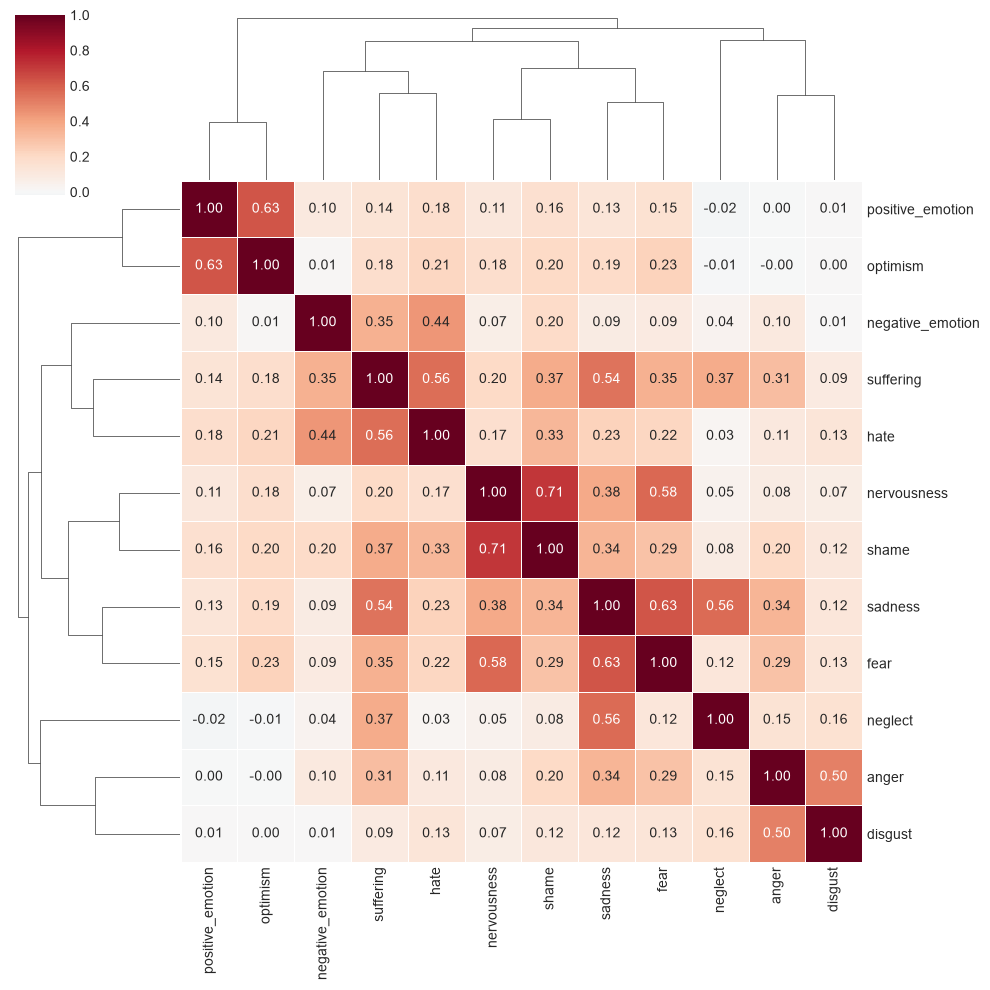

In [6]:
corr = emociones.corr()

plt.figure(figsize=(14,9))
sns.clustermap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.show()

El clustermap parece sugerir agrupaciones entre:
- Positive_emotion y optimism
- Nervousness y Shame
- Suffering y Hate
- Sadness y Fear
- Anger y Disgust

Para validar, se aplica Análisis Factorial Exploratorio que permita definir constructos que posteriormente se validarán con Análisis Factorial Confirmatorio

##### Análisis Factorial Exploratorio

Se obtienen los eigenvalores para estimar mediante diversos métodos el mejor número de factores

In [7]:
pca = PCA()
pca.fit(StandardScaler().fit_transform(emociones))
eigenvalues = pca.explained_variance_
eigen_df = pd.DataFrame({
    "Eigenvalue": eigenvalues
})

eigen_df

,Eigenvalue
0,3.594203
1,1.684963
2,1.404983
3,1.270378
4,1.193057
5,0.743556
6,0.596799
7,0.537609
8,0.350218
9,0.281129


###### **Criterio de Kaiser**

Consiste en conservar únicamente aquellos factores cuyos valores propios son mayores que 1. Esta regla heurística se basa en que, al trabajar con variables estandarizadas, cada variable original aporta una unidad de varianza al sistema. Por tanto, un factor solo se considera relevante si explica al menos tanta varianza como una variable individual. En consecuencia, los factores con valores propios superiores a la unidad se retienen para el análisis, mientras que aquellos con valores inferiores a 1 se descartan por representar una cantidad de información menor a la aportada por una variable original.

In [8]:
sum(eigenvalues > 1)

np.int64(5)

El criterio define 5 factores

###### **Criterio del codo**

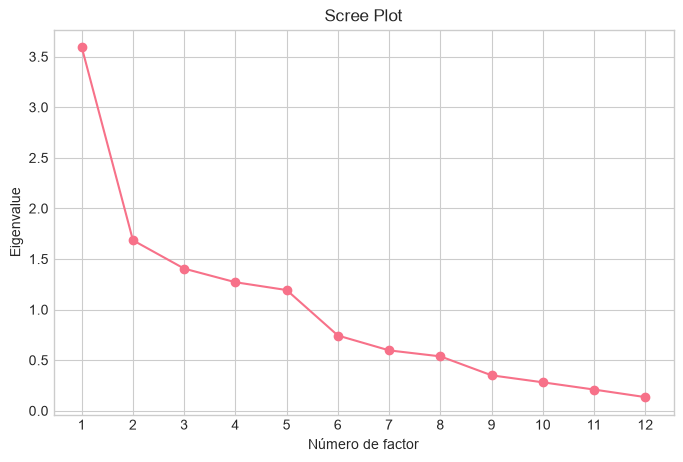

In [9]:

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(eigenvalues)+1, 1),
    eigenvalues,
    marker='o'
)

plt.xticks(list(range(1, len(eigenvalues)+1, 1)))

plt.xlabel("Número de factor")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

Se identifica que la curva se comienza a aplanar a partir del tercer factor. Para mantener la mayor información posible se define que el método del codo determinó como mejor valor 5 factores

###### **Análisis paralelo (Horn)**

El análisis de Horn compara los eigenvalores obtenidos con los eigenvalores esperados de muestras aleatorias con las dimensiones del problemas, y solo mantiene aquellas variables que explican más que el ruido aleatorio.

In [10]:
n_iter = 1000
random_eigen = np.zeros((n_iter, emociones.shape[1]))

for i in range(n_iter):

    random_data = np.random.normal(
        size=(emociones.shape[0], emociones.shape[1])
    )

    pca_random = PCA()
    pca_random.fit(random_data)

    random_eigen[i, :] = pca_random.explained_variance_

mean_random_eigen = random_eigen.mean(axis=0)
n_factors_parallel = np.sum(eigenvalues > mean_random_eigen)

print(
    f"Factores sugeridos por Análisis Paralelo: "
    f"{n_factors_parallel}"
)

Factores sugeridos por Análisis Paralelo: 5


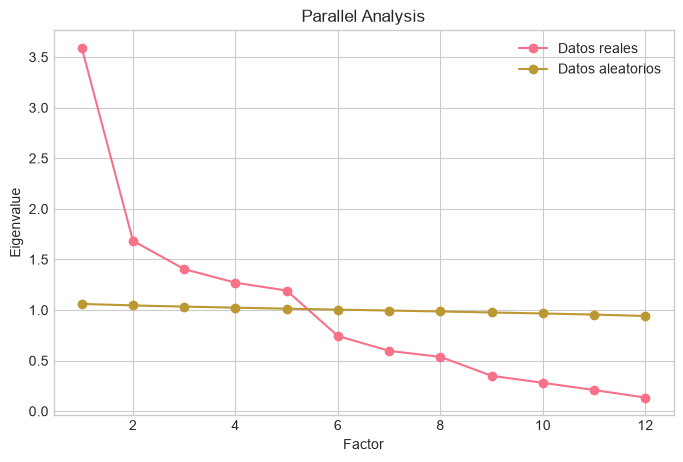

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, emociones.shape[1]+1),
    eigenvalues, 
    marker='o', 
    label='Datos reales')

plt.plot(
    range(1, emociones.shape[1]+1),
    mean_random_eigen,
    marker='o',
    label='Datos aleatorios'
)

plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.title("Parallel Analysis")
plt.legend()
plt.grid(True)

plt.show()

###### **Selección del mejor factor**

Los 3 métodos plantearon 5 factores como la mejor solución. Se interpretan:

In [12]:
fa = FactorAnalysis(
        n_components=5, rotation = "varimax", max_iter = 3000
    )

fa.fit(StandardScaler().fit_transform(emociones))

loadings = pd.DataFrame(
    fa.components_.T,
    index=emociones.columns,
    columns=[
        f"Factor_{i+1}"
        for i in range(5)
    ]
)

loadings

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5
negative_emotion,0.057152,0.000045,0.058885,-0.024775,0.556008
sadness,0.230326,0.943433,0.166860,0.094636,0.118400
suffering,0.112456,0.421317,0.192999,0.096405,0.637179
fear,0.495122,0.491222,0.188825,0.149799,0.049870
nervousness,0.984217,0.155487,0.007594,0.067659,0.022654
anger,0.050187,0.170747,0.975709,-0.014473,0.070221
shame,0.692268,0.118029,0.127581,0.103752,0.297589
disgust,0.067458,0.016580,0.501929,-0.001849,0.046119
hate,0.133025,0.094939,0.036811,0.151991,0.753496
neglect,-0.044860,0.597551,0.042519,-0.068096,0.076999


- **Factor 1:** (Ansiedad, miedo y verguenza) Parece agrupar en general la ansiedad (Fear, Nervousness, Shame)
- **Factor 2:** (Sufrimiento y tristeza) Agrupa sentimientos de tristeza, sufrimiento y abandono (Sadness, Neglect, suffering)
- **Factor 3:** (Ira) Agrupa emociones reactivas como la ira y el disgusto (Anger y disgust)
- **Factor 4:** (Afectos positivos) Agrupa emociones positivas y de optimismo (Positive_emotion y optimism)
- **Factor 5:** (Odio y negatividad) Agrupa negatividad, odio y otras categorías relacionadas (Negative_emotion y hate)

Teniendo en cuenta los factores, se transforman, se agrupan y se añaden al dataset para que sean parte de los atributos del grafo

In [ ]:
scores = fa.transform(StandardScaler().fit_transform(emociones))
scores_df = pd.DataFrame(scores, columns = ["Anxiety_fear", "Sadness_suffering", "Anger_disgust", "Positive", "Hate_negativity"])
df = pd.concat([df, scores_df], axis=1)
